In [1]:
import sys
from pathlib import Path
import os
import tifffile as tiff
import numpy as np

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

In [4]:
my_data_path = "../data/experimental"
shape = "chri_1"
file_name = f"{shape}.tif"
file_path = os.path.join(my_data_path, "sam3", file_name)
# file_path = f"/gscratch/matsulab/sim/sam3/input/chri_1.tif"
cryoet = tiff.imread(file_path)
cryoet = cryoet / cryoet.max()
# cryoet = 1 - cryoet
# cryoet = -cryoet / cryoet.max()
print(cryoet.shape)
print(cryoet.max())
print(cryoet.min())

(33, 299, 299)
1.0
0.0


In [8]:
from data_generation.preprocess import downsample, clahe_volume_slicewise_fast

z_min = 0; z_max = cryoet.shape[0]
y_min = 0; y_max = cryoet.shape[1]
x_min = 0; x_max = cryoet.shape[2]
GRID_SIZE = 299

normalized = downsample(cryoet, x_min, x_max, y_min, y_max, z_min, z_max, GRID_SIZE = GRID_SIZE)

clahe_vol = clahe_volume_slicewise_fast(normalized, clipLimit=2.0, tileGridSize=(16, 16))
clahe_vol = clahe_vol/255

Downsampled shape: (33, 299, 299)
Padded shape:     (299, 299, 299)
Resized shape:    (299, 299, 299)
Normalized shape: (299, 299, 299)


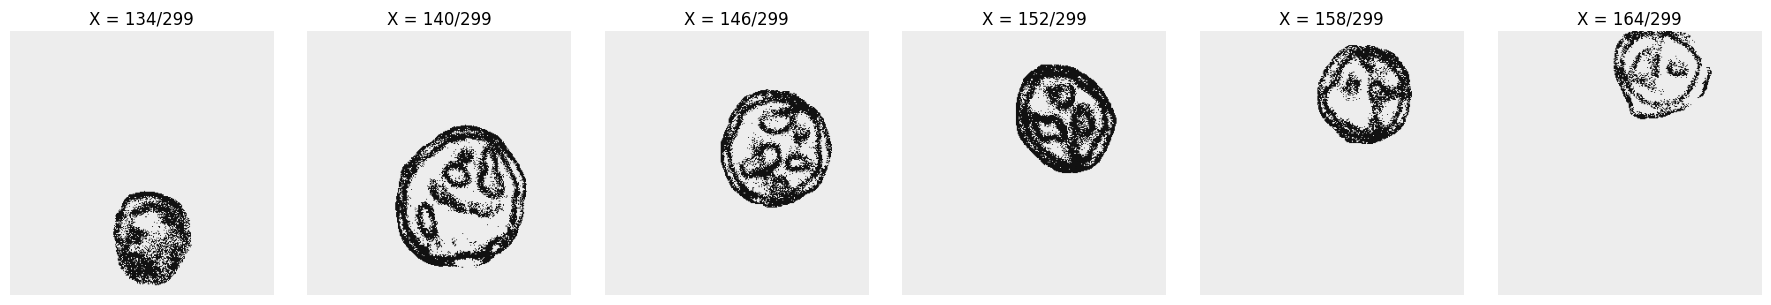

In [20]:
# Visualize data
from data_generation.mesh_to_cryoet import plot_multiple_slices

n_slices = 8
threshold = 0.8
threshold = None

# slices = [133, 134]
slices = np.arange(134, 166, 6)
# slices = np.arange(0, 33, 6)

# visualize = normalized
visualize = clahe_vol
# visualize = cryoet

# plot_multiple_slices(visualize, axis='z', num_slices=n_slices, thre=threshold)
# plot_multiple_slices(visualize, axis='y', num_slices=n_slices, thre=threshold)
# plot_multiple_slices(visualize, axis='x', num_slices=n_slices, thre=threshold)

plot_multiple_slices(visualize, axis='x', slices=slices, thre=threshold)

In [32]:
from data_generation.preprocess import downsample_binary_mask_to_fraction

in_min   = 0
in_max   = 0.01
out_min  = 0.24
out_max  = 0.27
edge_min = 0.6
edge_max = 1.0
target_edge = 1.
target_bulk = 0.01
target_out  = 0.
target_in   = 0.

slice_min   = 134
slice_max   = 164

Z = clahe_vol.shape[0]
z = np.arange(Z)[:, None, None]   # shape (Z,1,1)

edge    = (clahe_vol >= edge_min) & (clahe_vol <= edge_max)
# bulk    = (~edge)
bulk = (~edge) & (z >= slice_min) & (z <= slice_max)
outside = (normalized >= out_min)  & (normalized <= out_max)
inside  = (normalized >= in_min)   & (normalized <= in_max)


edge    = downsample_binary_mask_to_fraction(edge,    target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk,    target_frac=target_bulk, seed=0)
outside = downsample_binary_mask_to_fraction(outside, target_frac=target_out, seed=0)
inside  = downsample_binary_mask_to_fraction(inside , target_frac=target_in, seed=0)

# outside = outside & (~edge)
# inside = inside & (~edge)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)
outside = outside.astype(np.float32)
inside = inside.astype(np.float32)

print("edge: ",    edge.sum())
print("bulk: ",    bulk.sum())
print("outside: ", outside.sum())
print("inside: ",  inside.sum())

edge:  187486.0
bulk:  267309.0
outside:  0.0
inside:  0.0


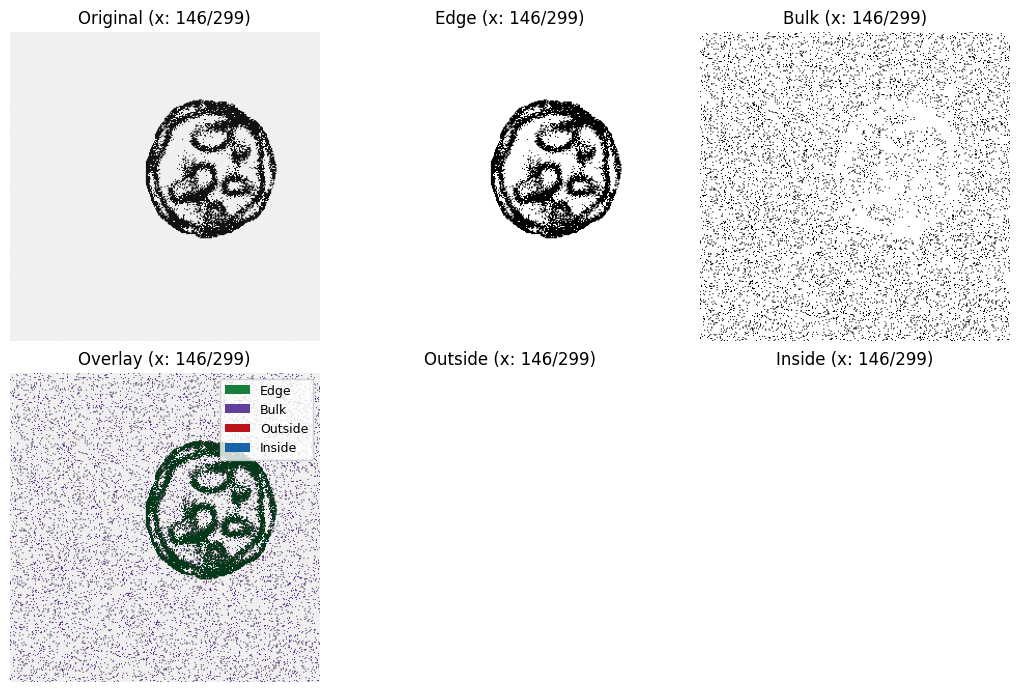

In [33]:
# Visualize data
from data_generation.preprocess import plot_edge_and_region, overlay_masks_on_cryoet, plot_edge_region_with_bulk_2rows

axis = "x"
slice_index = 146
# slice_index = 170

# plot_edge_and_region(normalized, edge, outside, inside, axis=axis, slice_index=slice_index)
# overlay_masks_on_cryoet(normalized, edge, outside, inside, axis=axis, slice_index=slice_index, alpha=0.8)

plot_edge_region_with_bulk_2rows(normalized, edge, bulk, outside, inside, axis=axis, slice_index=slice_index, alpha=0.8)

In [4]:
## To reload

import importlib
import data_generation.preprocess as preprocess

importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>

In [34]:
## Reformat and save data

from data_generation.preprocess import build_data_sign_from_masks, build_data_edge_from_masks
import mrcfile

data_sign = build_data_sign_from_masks(
    outside=outside,
    inside=inside,
    volume_shape=normalized.shape,
)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=normalized.shape,
)

print("data_sign count: ", data_sign["sign"].shape)
print("data_edge count: ", data_edge["edge"].shape)

save_file = f"../data/experimental/sign/{shape}.npz"
np.savez(
    save_file,
    points=np.asarray(data_sign["points"]),
    sign=np.asarray(data_sign["sign"]),
)

save_file = f"../data/experimental/edge/{shape}.npz"
np.savez(
    save_file,
    points=np.asarray(data_edge["points"]),
    edge=np.asarray(data_edge["edge"]),
)

edge_mrc = f"../data/experimental/masked/{shape}.mrc"
with mrcfile.new(edge_mrc, overwrite=True) as mrc:
    mrc.set_data(edge.astype(np.float32))

data_sign count:  (0,)
data_edge count:  (454795,)


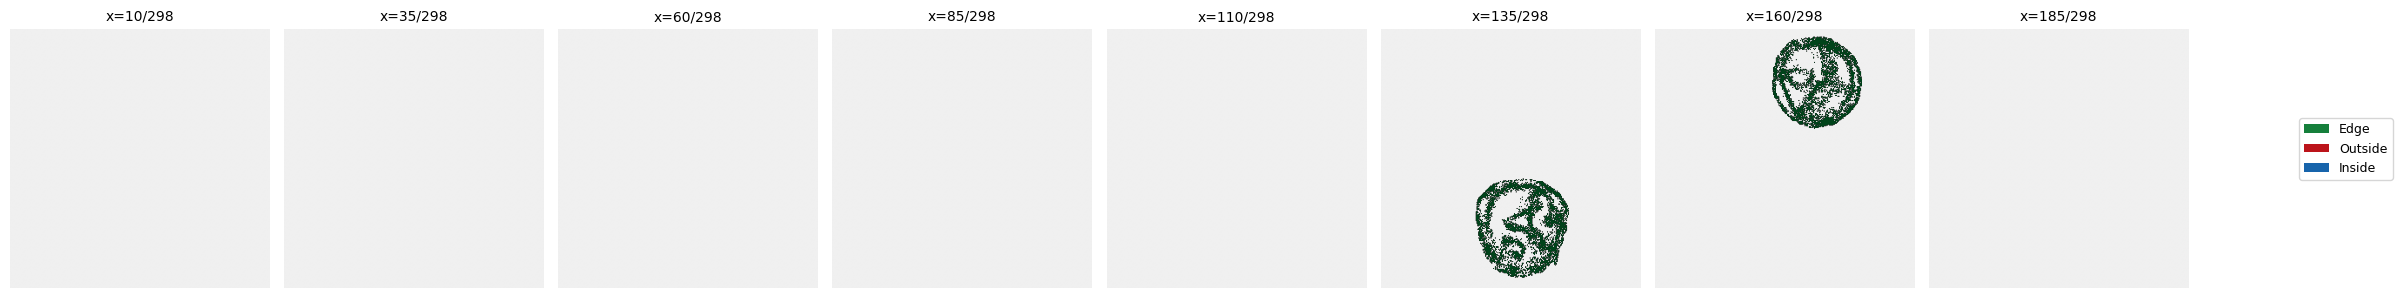

In [23]:
from data_generation.preprocess import overlay_masks_on_cryoet_slices

# slice_index = [23, 27, 32, 35, 39]
slice_index = np.arange(10, 208, 25)
# slice_index = np.arange(10, 360, 60)
# slice_index = [50, 60, 70, 80, 90]
# slice_index = [65, 67, 70, 73, 75]
axis = "x"

overlay_masks_on_cryoet_slices(
    cryoet=normalized,
    edge=edge,
    outside=outside,
    inside=inside,
    axis=axis,
    slice_indices=slice_index,
    alpha=1,
)


In [15]:
import mrcfile
shape = "mend_3"
ori_mrc = f"../data/experimental/sam3/mrc/{shape}.mrc"
with mrcfile.new(ori_mrc, overwrite=True) as mrc:
    # mrc.set_data(normalized.astype(np.float32))
    # mrc.set_data(clahe_vol.astype(np.float32))

In [52]:
vol_clahe = clahe_volume_slicewise_fast(normalized, clipLimit=2.0, tileGridSize=(16, 16))
vol_clahe = vol_clahe/255

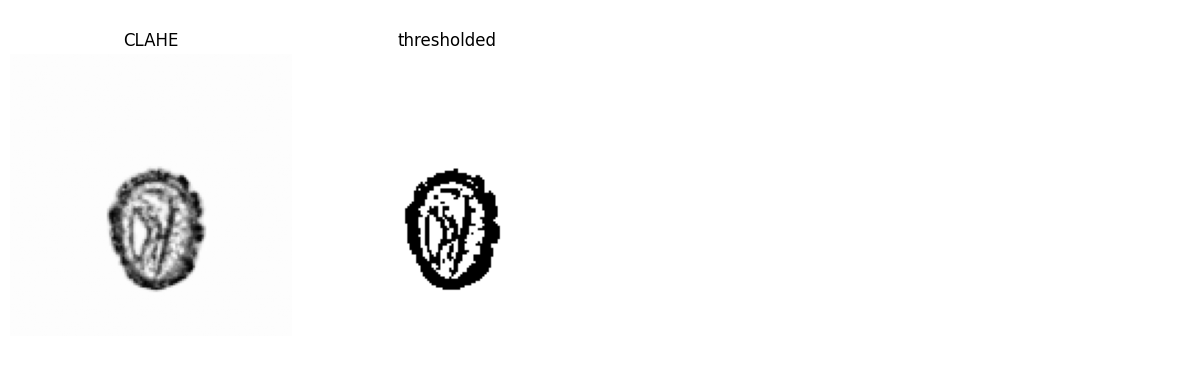

In [59]:
x = 60
img = vol_clahe[x, :, :]
binary = img > 0.4

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(img, cmap="gray_r")
axes[0].set_title("CLAHE")

axes[1].imshow(binary, cmap="gray_r")
axes[1].set_title("thresholded")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

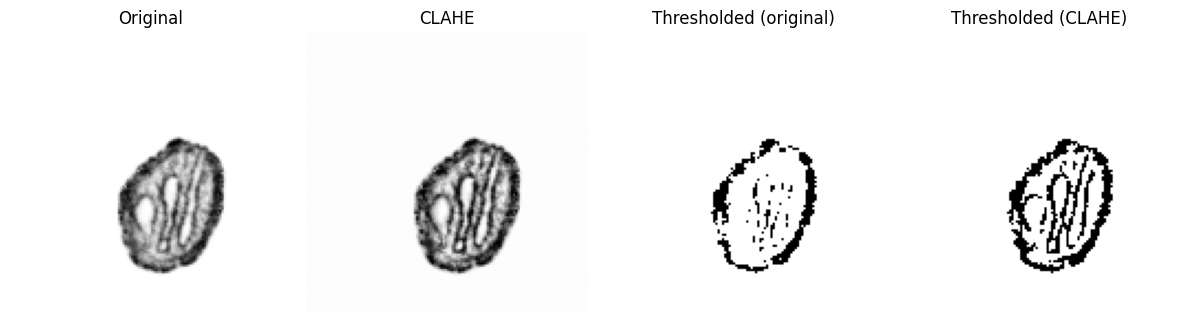

In [62]:
# test
import cv2

x = 30
img = normalized[x, :, :]

clahe = cv2.createCLAHE(
    clipLimit=2.0,      # contrast limiting
    tileGridSize=(16,16)  # local window size
)

img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
cl1 = clahe.apply(img_u8)
cl1 = cl1 / 255

thre = 0.6
binary_ori = img > thre
binary_cl1 = cl1 > thre


fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(img, cmap="gray_r")
axes[0].set_title("Original")

axes[1].imshow(cl1, cmap="gray_r")
axes[1].set_title("CLAHE")

axes[2].imshow(binary_ori, cmap="gray_r")
axes[2].set_title("Thresholded (original)")

axes[3].imshow(binary_cl1, cmap="gray_r")
axes[3].set_title("Thresholded (CLAHE)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


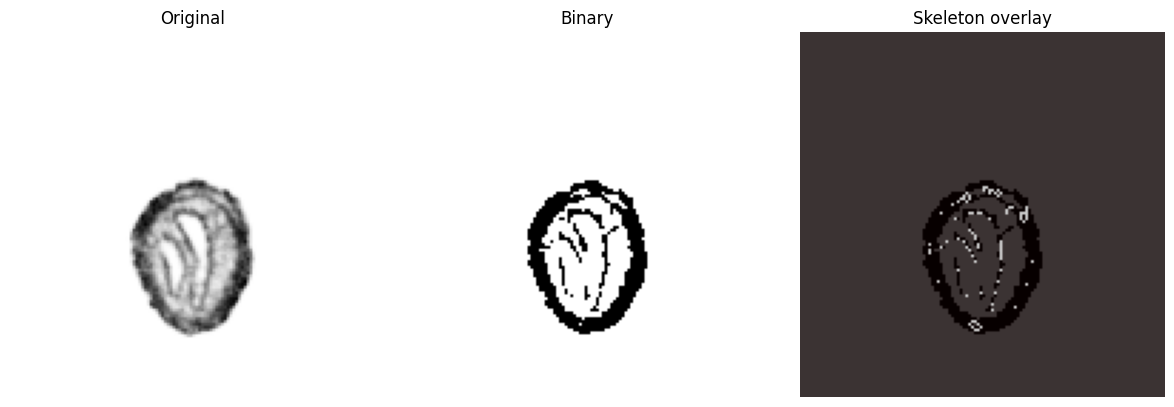

In [19]:
## TEST

import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# Binarize and skeletonize (slice-by-slice)
binary = normalized > 0.4
skeleton = skeletonize(binary)

# Choose slice
x = 64   # middle slice

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(normalized[x, :, :], cmap="gray_r")
axes[0].set_title("Original")

axes[1].imshow(binary[x, :, :], cmap="gray_r")
axes[1].set_title("Binary")

axes[2].imshow(binary[x, :, :], cmap="gray_r")
axes[2].imshow(skeleton[x, :, :], cmap="hot", alpha=0.8)
axes[2].set_title("Skeleton overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()



In [35]:
import mrcfile
import numpy as np
output_file = f"../data/experimental/sam3/mrc/{shape}.mrc"
with mrcfile.new(output_file, overwrite=True) as mrc:
    # mrc.set_data(normalized.astype(np.float32))
    mrc.set_data(clahe_vol.astype(np.float32))

In [ ]:
## Visualize sampled points
from pinn.utils import visualize_sign_sampling_mrc

GRID_SIZE = 128
shape = "mend_1"
# save_sign_dir = f"../outputs/logs/{shape}/manual_signs.npz"
save_sign_dir = f"../data/experimental/sign/{shape}.npz"
# save_sign_dir = f"../outputs/logs/mito_1/manual_signs_inm.npz"
# mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
mrc_file_path = f"../data/experimental/masked/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
checkpoint_data = cryoET_data

signs = load_sign_data(save_sign_dir, perm=(0,1,2))
out = visualize_sign_sampling_mrc(grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, cryoET_data=cryoET_data, signs=signs, slice_thickness_vox=0)

# signs